# *Ido Weinstock - HW2 DS course*

## Context

According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths.
This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.

## Attribute

The dataset used in this study is sourced from Kaggle (uploaded by fedesoriano), with its original medical origin designated as a confidential source. In healthcare data science, such confidentiality is standard practice rather than an anomaly, adhering to strict patient privacy regulations such as HIPAA and GDPR. Despite the absence of a specific institutional identifier, this dataset serves as a widely accepted benchmark in both academia and industry for addressing key machine learning challenges, including imbalanced classification and missing data imputation. Sanity checks and feature distributions—such as the clear correlations between age, hypertension, glucose levels, and stroke risk—demonstrate high consistency with established clinical literature, confirming the dataset's validity for exploratory data analysis and predictive modeling.

## Imports

*Dataset loading*

In [2]:
import pandas as pd
import numpy as np
import plotnine as pln
import kagglehub

In [3]:
dataset_path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
df = pd.read_csv(f"{dataset_path}/healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# EDA

## *1. Data cleaning and preprocesing*

### *Dataset shape*

In [4]:
df.shape

(5110, 12)

*Rows*: 5110

*Columns*: 12

*Variables*:
1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12) stroke: 1 if the patient had a stroke or 0 if not
*Note: "Unknown" in smoking_status means that the information is unavailable for this patient

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


### *Null values*

The dataset contains 201 BMI missing values, accounting for approximately 3.9% of the total records (201/5,110). This represents a negligible proportion of the overall data.

In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### *Dupliacations*

#### *Full duplication*

There are no full duplications. Each person showed only once.

In [7]:
df.duplicated().sum()

np.int64(0)

#### *Partial duplication*

*Partial Duplicates & Feature Sensitivity Analysis*

An evaluation of feature removal sensitivity indicates that the dataset contains zero full duplicate rows across all 11 features. However, the unique identity of individual records relies almost entirely on high-precision continuous metrics.

* **Critical Discriminator:** The feature `avg_glucose_level` acts as the primary barrier against row collisions. Removing it triggers a massive surge of **+3,487 partial duplicates** (jumping from 5 to 3,492), revealing widespread demographic and categorical overlap across patients.
* **Low-Impact Features:** Removing `stroke`, `smoking_status`, and `bmi` yields a negligible impact ($\Delta \le +5$), indicating these attributes do not independently drive record uniqueness.
* **Cohort Redundancy:** The rapid accumulation of duplicates upon stripping categorical features (`Residence_type`, `work_type`, `ever_married`) confirms that the dataset consists of recurring demographic cohorts differentiated mainly by continuous clinical measurements.

In [8]:
# Exclude the unique identifier column ('id') to prevent artificial uniqueness
analysis_cols = [col for col in df.columns if col.lower() != "id"]

# Define key demographic and medical indicators for cohort identification
clinical_features = [
    "gender",
    "age",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
]

# Locate rows sharing identical demographic and medical profiles
partial_dups_mask = df.duplicated(subset=clinical_features, keep=False)
partial_duplicates_df = df[partial_dups_mask].sort_values(by=["age", "gender"])

# Calculate summary statistics for partial duplication
total_partial_rows = len(partial_duplicates_df)
effective_extra_rows = df.duplicated(subset=clinical_features).sum()

# ==============================================================================
# Sequential Feature Sensitivity & Discriminating Power Analysis
# ==============================================================================

print("\n=== Sequential Feature Removal Impact ===")
prev_dup_count = 0

# Iteratively prune columns backwards to measure each feature's discriminating power
for i in range(len(analysis_cols), 0, -1):
    subset = analysis_cols[:i]
    dup_count = df.duplicated(subset=subset).sum()

    if i < len(analysis_cols):
        delta = dup_count - prev_dup_count
        dropped_col = analysis_cols[i]
        print(
            f"Removing '{dropped_col}' ({i} features left): {dup_count} duplicates (Δ = +{delta})"
        )
    else:
        print(
            f"Full feature set baseline ({i} features): {dup_count} duplicates"
        )

    prev_dup_count = dup_count


=== Sequential Feature Removal Impact ===
Full feature set baseline (11 features): 0 duplicates
Removing 'stroke' (10 features left): 0 duplicates (Δ = +0)
Removing 'smoking_status' (9 features left): 0 duplicates (Δ = +0)
Removing 'bmi' (8 features left): 5 duplicates (Δ = +5)
Removing 'avg_glucose_level' (7 features left): 3492 duplicates (Δ = +3487)
Removing 'Residence_type' (6 features left): 4019 duplicates (Δ = +527)
Removing 'work_type' (5 features left): 4524 duplicates (Δ = +505)
Removing 'ever_married' (4 features left): 4686 duplicates (Δ = +162)
Removing 'heart_disease' (3 features left): 4796 duplicates (Δ = +110)
Removing 'hypertension' (2 features left): 4904 duplicates (Δ = +108)
Removing 'age' (1 features left): 5107 duplicates (Δ = +203)


### *Suspected values*

There are no value placholders or impossible values.

#### *negative values*

In [9]:
numeric_df = df.select_dtypes(include = 'number')
negative_values_df = numeric_df[numeric_df<0] # zero values won't be in that df

# .dropna(how='all'): Drops rows that contain only NaN values (rows without any negative numbers).
df_negatives_cleaned = negative_values_df.dropna(how="all")

print("--- DataFrame showing only negative values (non-negatives as NaN) ---")
df_negatives_cleaned.head()

--- DataFrame showing only negative values (non-negatives as NaN) ---


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke


There are no negative values

#### *age & marriage contradictions*

In [10]:
underage_marriage_df = df[
    (df["age"]< 18) & (df["ever_married"] == "Yes")
]

underage_marriage_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


There are no people under the leagal age of marriage in the dataset

#### *BMI outliers*

In [11]:
bmi_outliers_df = df[
    (df["bmi"] < 10) & (df["bmi"]>60)
]

bmi_outliers_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


There are no BMI outliers

## *2. Univariate analysis*

The dataset exhibits substantial variation in feature cardinality, ranging from binary indicators and low-cardinality categorical variables to high-cardinality continuous numerical features (int/float).

#### *Gender*

There is one person that defined himself as other. this is outlier.
I will remove it before training.

The gender distribution is close to the global population distribution - 50/50.

In [12]:
df["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

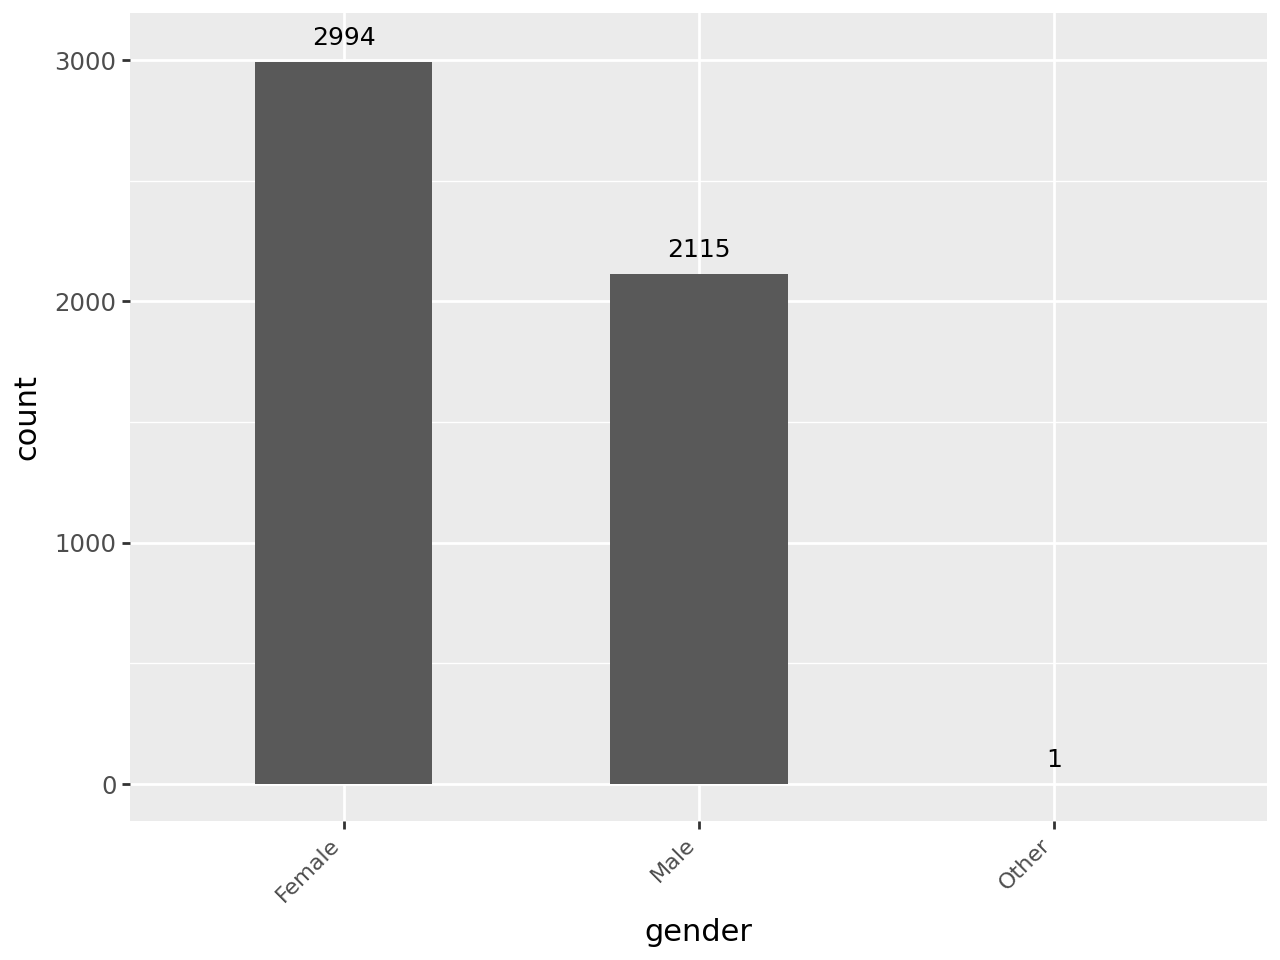

In [13]:
(
    pln.ggplot(df, pln.aes(x="gender"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Age*

Tere is pretty uniform distribution of samples

In [14]:
df["age"].value_counts()

age
78.00    102
57.00     95
52.00     90
54.00     87
51.00     86
        ... 
1.40       3
0.48       3
0.16       3
0.40       2
0.08       2
Name: count, Length: 104, dtype: int64

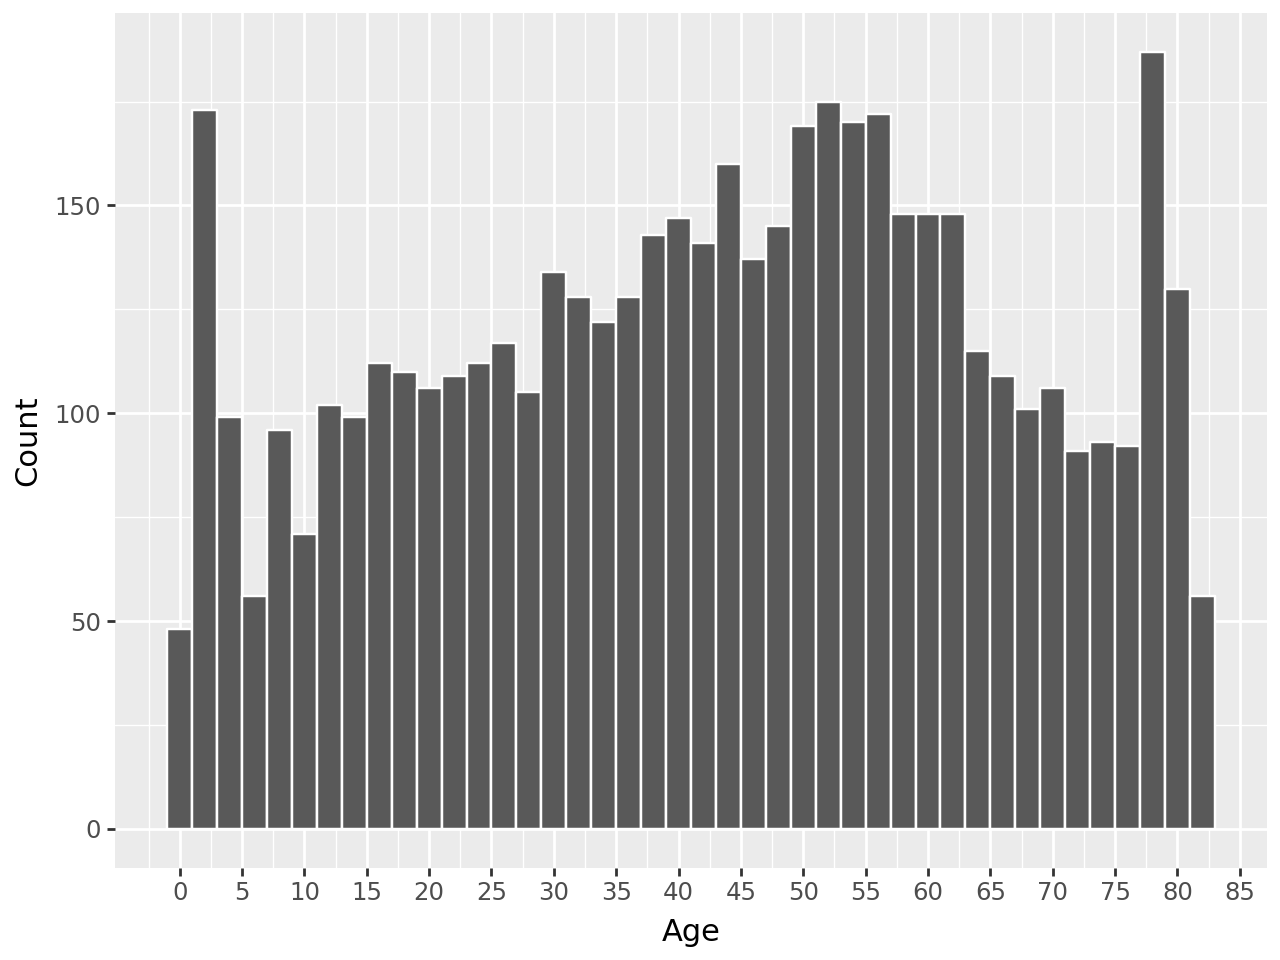

In [15]:
(
    pln.ggplot(df, pln.aes(x="age"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 90, 5)
    )
    + pln.labs(x="Age", y="Count")
)

In [16]:
df["age"].describe()

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

#### *Hypertension*

hypertension = over blood flow preasure.

Most of the population has no history of hypertension. The data make sense.

In [17]:
df["hypertension"].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

In [18]:
df["hypertension"].describe()

count    5110.000000
mean        0.097456
std         0.296607
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: hypertension, dtype: float64

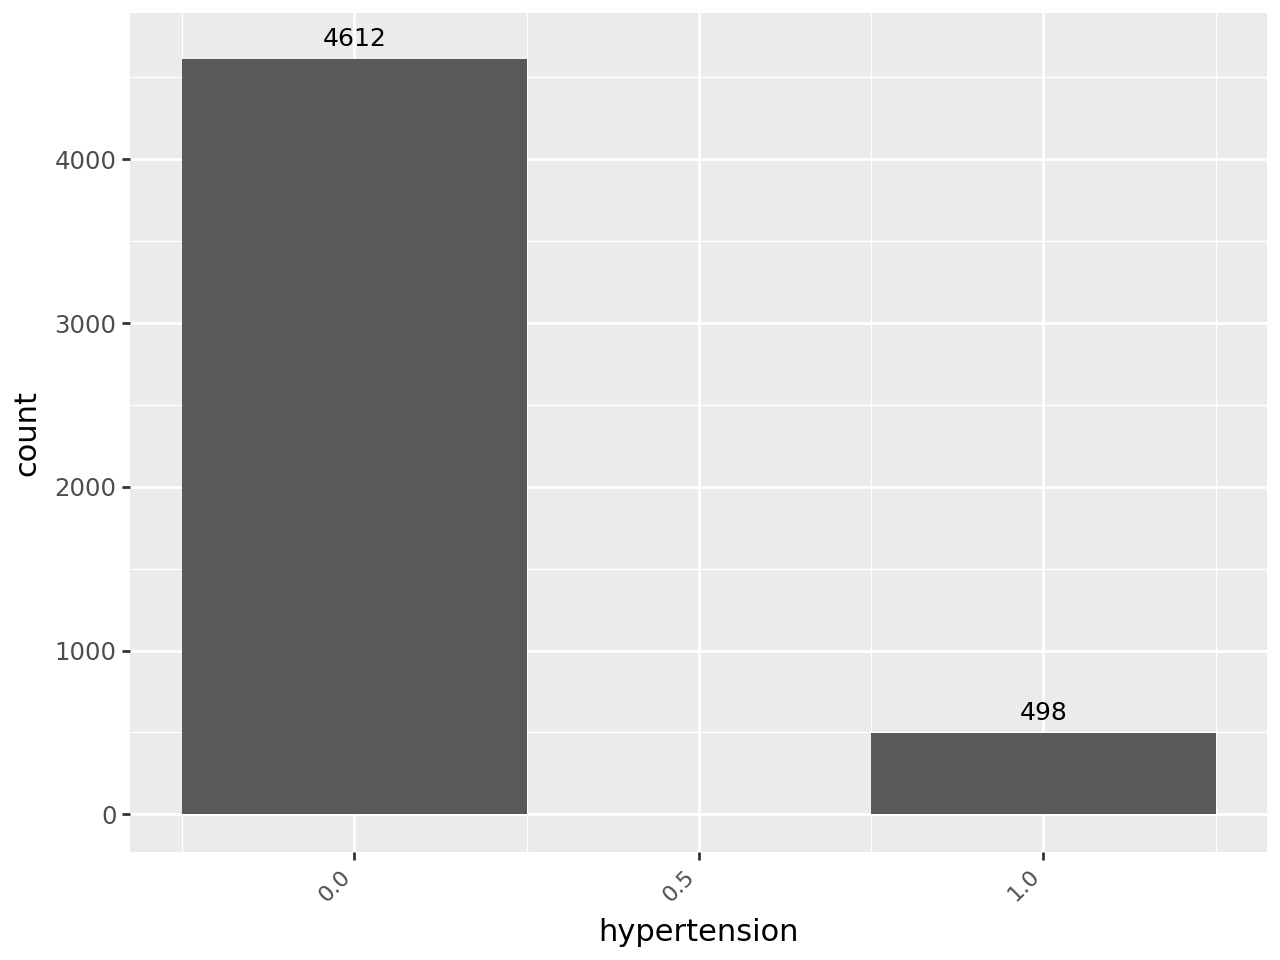

In [19]:
(
    pln.ggplot(df, pln.aes(x="hypertension"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Heart disease*

Most of the population has no history of heart disease. The data make sense.

In [20]:
df["heart_disease"].value_counts()

heart_disease
0    4834
1     276
Name: count, dtype: int64

In [21]:
df["heart_disease"].describe()


count    5110.000000
mean        0.054012
std         0.226063
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: heart_disease, dtype: float64

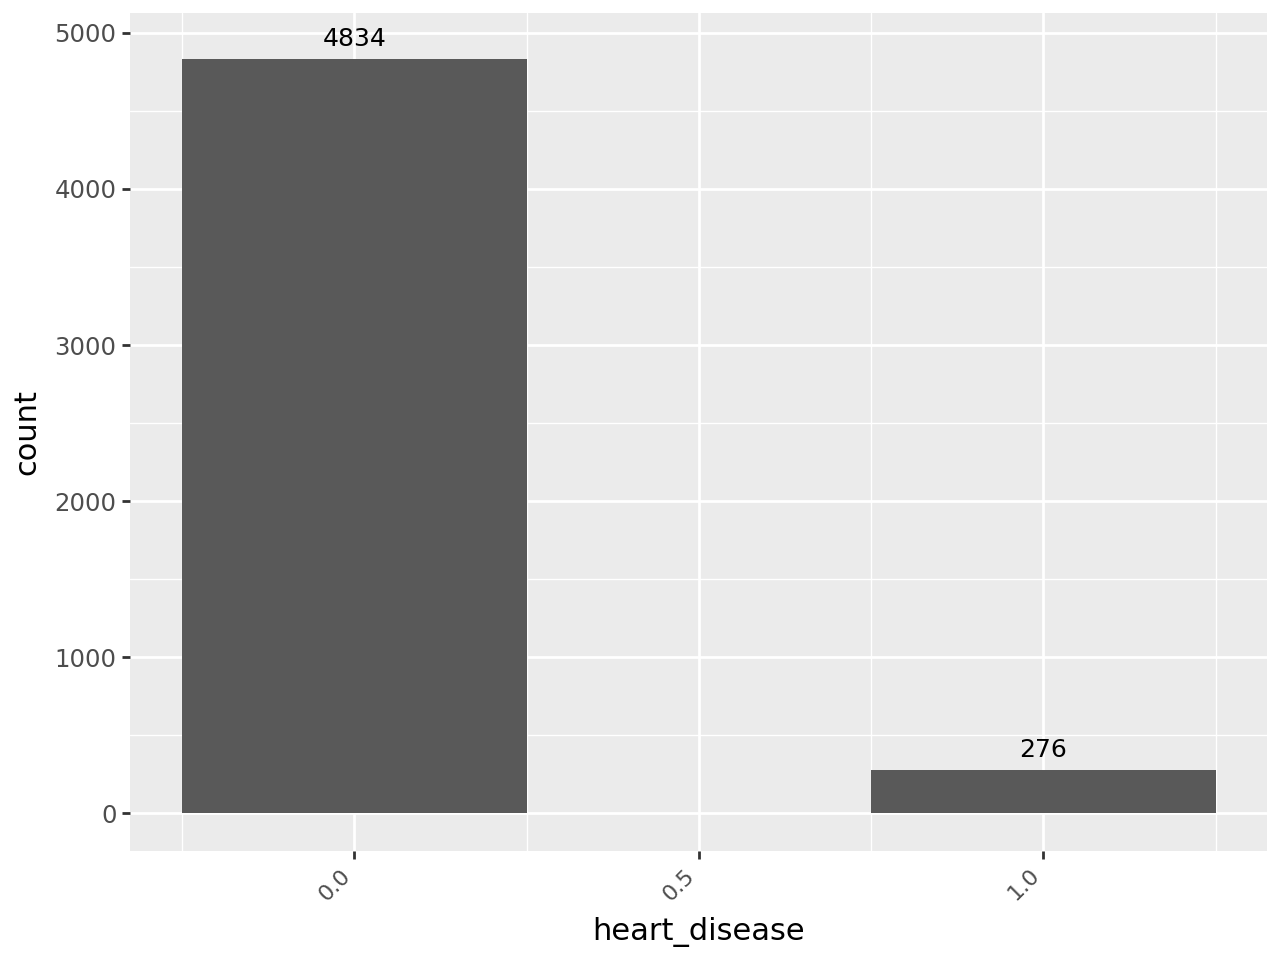

In [22]:
(
    pln.ggplot(df, pln.aes(x="heart_disease"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Marriage*

##### *General*

Proper marraiage distribution. There are no youth marriage cases.

In [23]:
df["ever_married"].value_counts()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

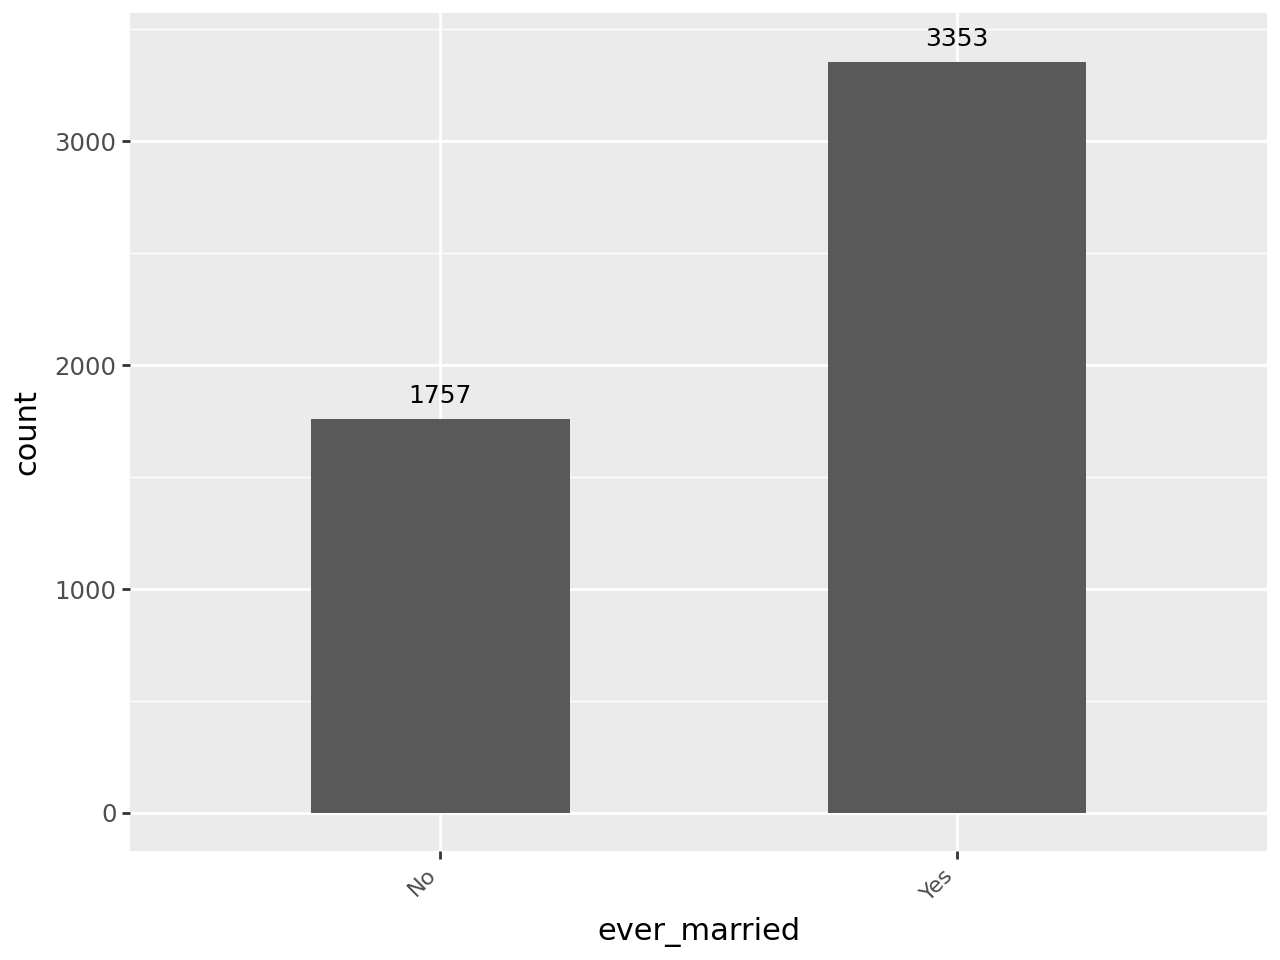

In [24]:
(
    pln.ggplot(df, pln.aes(x="ever_married"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

##### *Married people analysis*

In [25]:
married_df = df[df["ever_married"] == "Yes"].copy()
married_df["age"].describe()

count    3353.000000
mean       54.342082
std        15.527678
min        18.000000
25%        42.000000
50%        54.000000
75%        66.000000
max        82.000000
Name: age, dtype: float64

In [26]:
married_df["age"].value_counts()

age
78.0    89
57.0    87
54.0    83
52.0    83
53.0    81
        ..
22.0     7
21.0     6
20.0     4
19.0     2
18.0     1
Name: count, Length: 65, dtype: int64

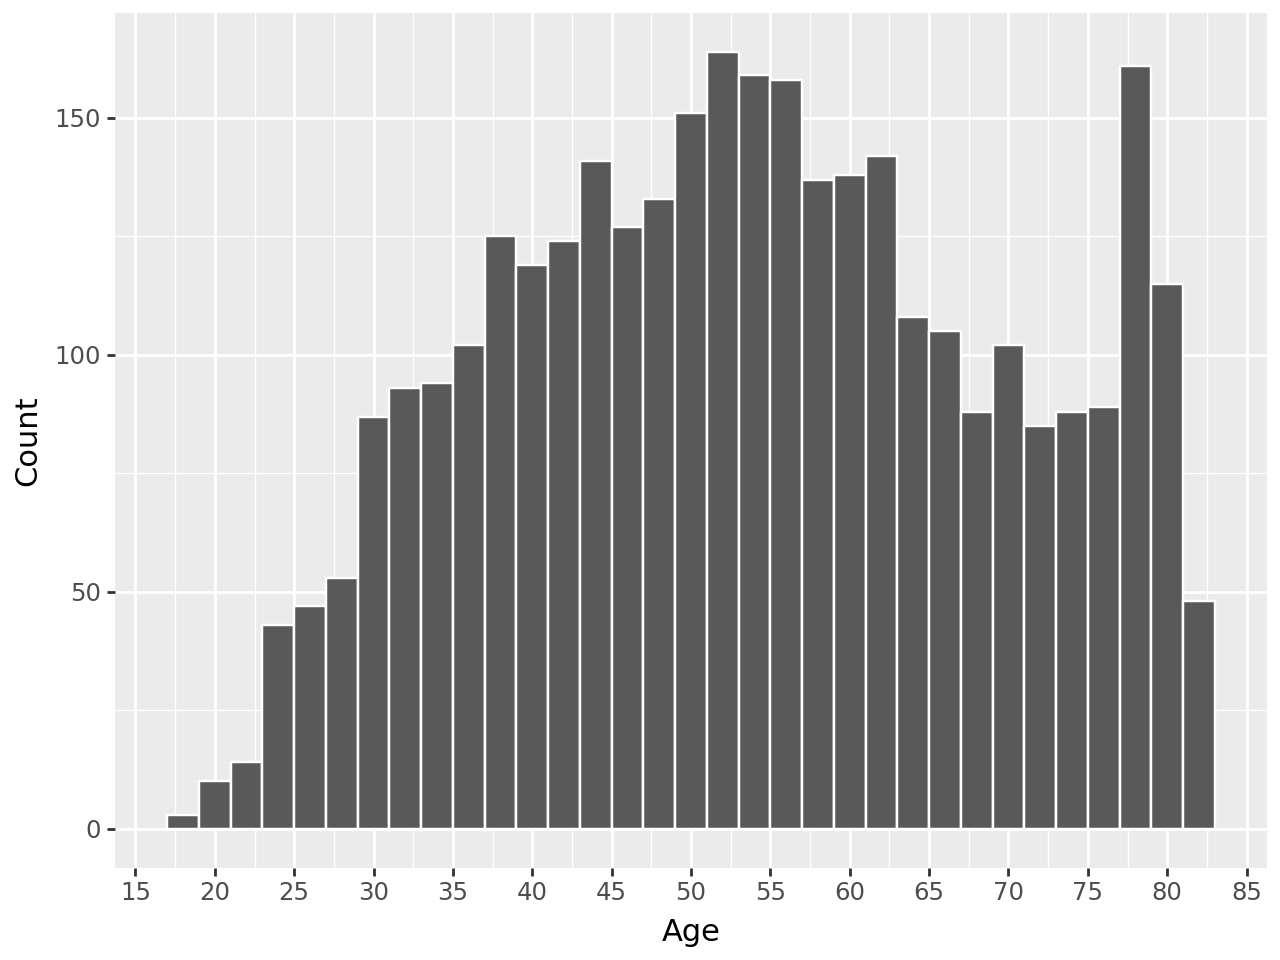

In [27]:
(
    pln.ggplot(married_df, pln.aes(x="age"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 90, 5)
    )
    + pln.labs(x="Age", y="Count")
)

##### *Not married analysis*

In [28]:
not_married_df = df[df["ever_married"] == "No"].copy()
not_married_df["age"].describe()

count    1757.000000
mean       22.014229
std        18.474467
min         0.080000
25%         9.000000
50%        18.000000
75%        28.000000
max        82.000000
Name: age, dtype: float64

In [29]:
not_married_df["age"].value_counts()

age
5.0     65
17.0    60
18.0    59
8.0     58
23.0    57
        ..
74.0     2
63.0     2
77.0     1
70.0     1
72.0     1
Name: count, Length: 103, dtype: int64

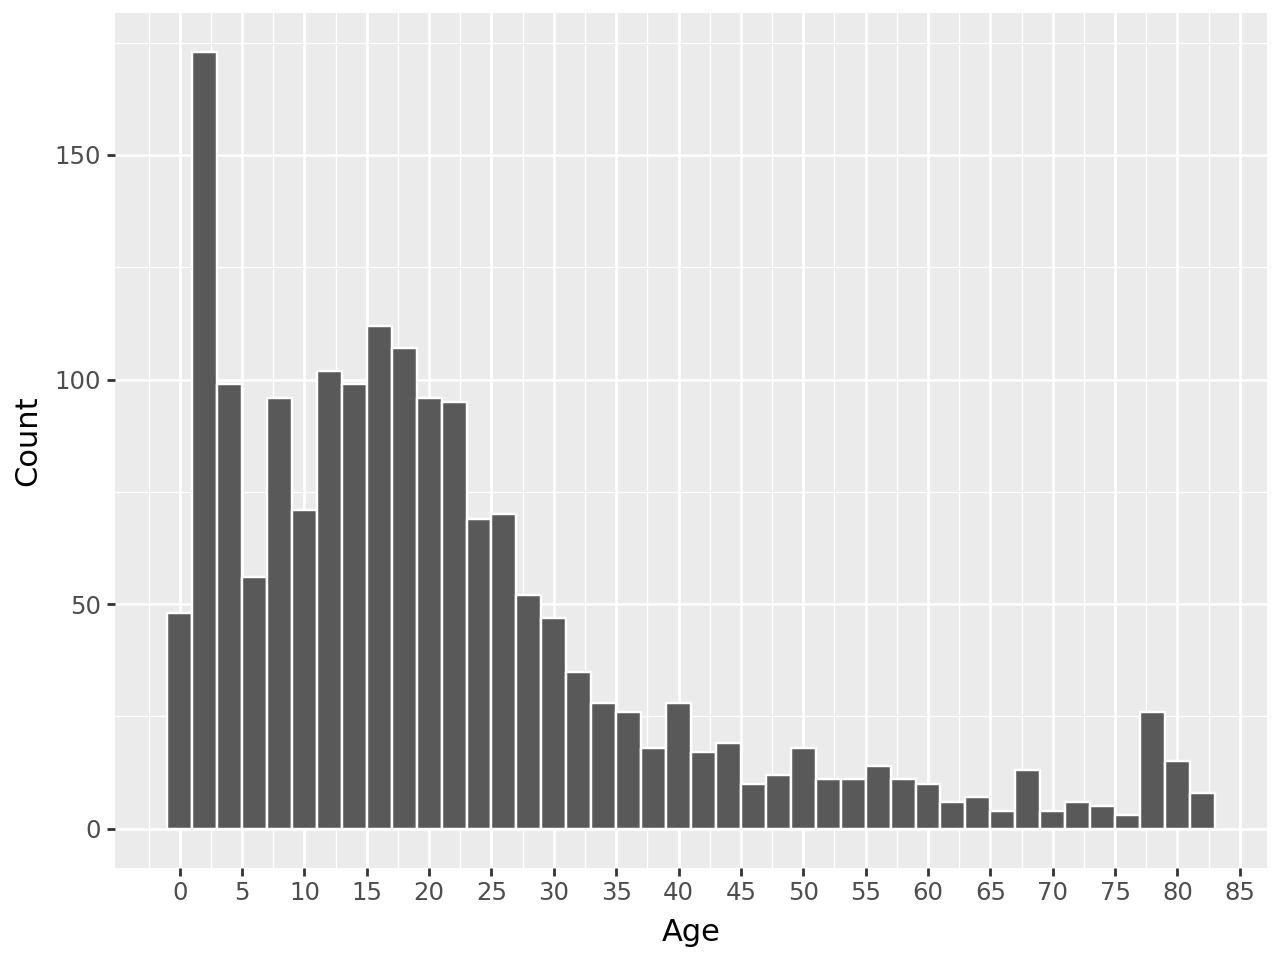

In [30]:
(
    pln.ggplot(not_married_df, pln.aes(x="age"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 90, 5)
    )
    + pln.labs(x="Age", y="Count")
)

The majority of the not married are children as expected.

#### *Work type*

##### *General*

The majority of the sampled people in the data are private workers. represents the entire population.

In [31]:
df["work_type"].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

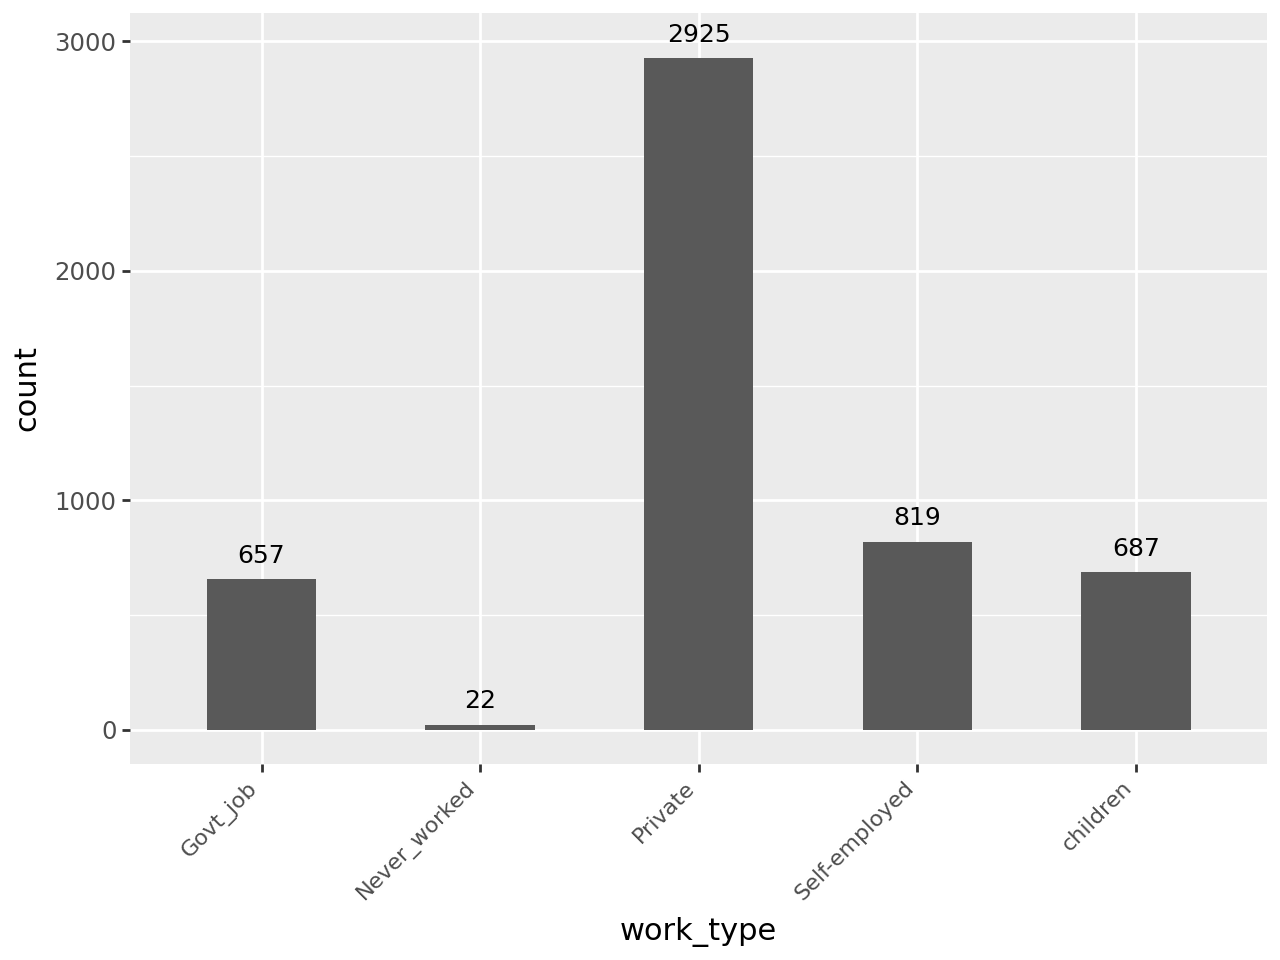

In [32]:
(
    pln.ggplot(df, pln.aes(x="work_type"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

##### *Work type - age analysis*

In [33]:
work_age_stats = df.groupby("work_type")["age"]
work_age_stats.describe()

,count,mean,std,min,25%,50%,75%,max
work_type,,,,,,,,
Govt_job,657.0,50.879756,15.438879,14.00,40.00,51.0,62.0,82.0
Never_worked,22.0,16.181818,2.342899,13.00,14.25,16.0,17.0,23.0
Private,2925.0,45.503932,18.444200,8.00,30.00,45.0,59.0,82.0
Self-employed,819.0,60.201465,16.835961,7.00,49.00,63.0,75.0,82.0
children,687.0,6.841339,4.533364,0.08,2.00,6.0,11.0,16.0


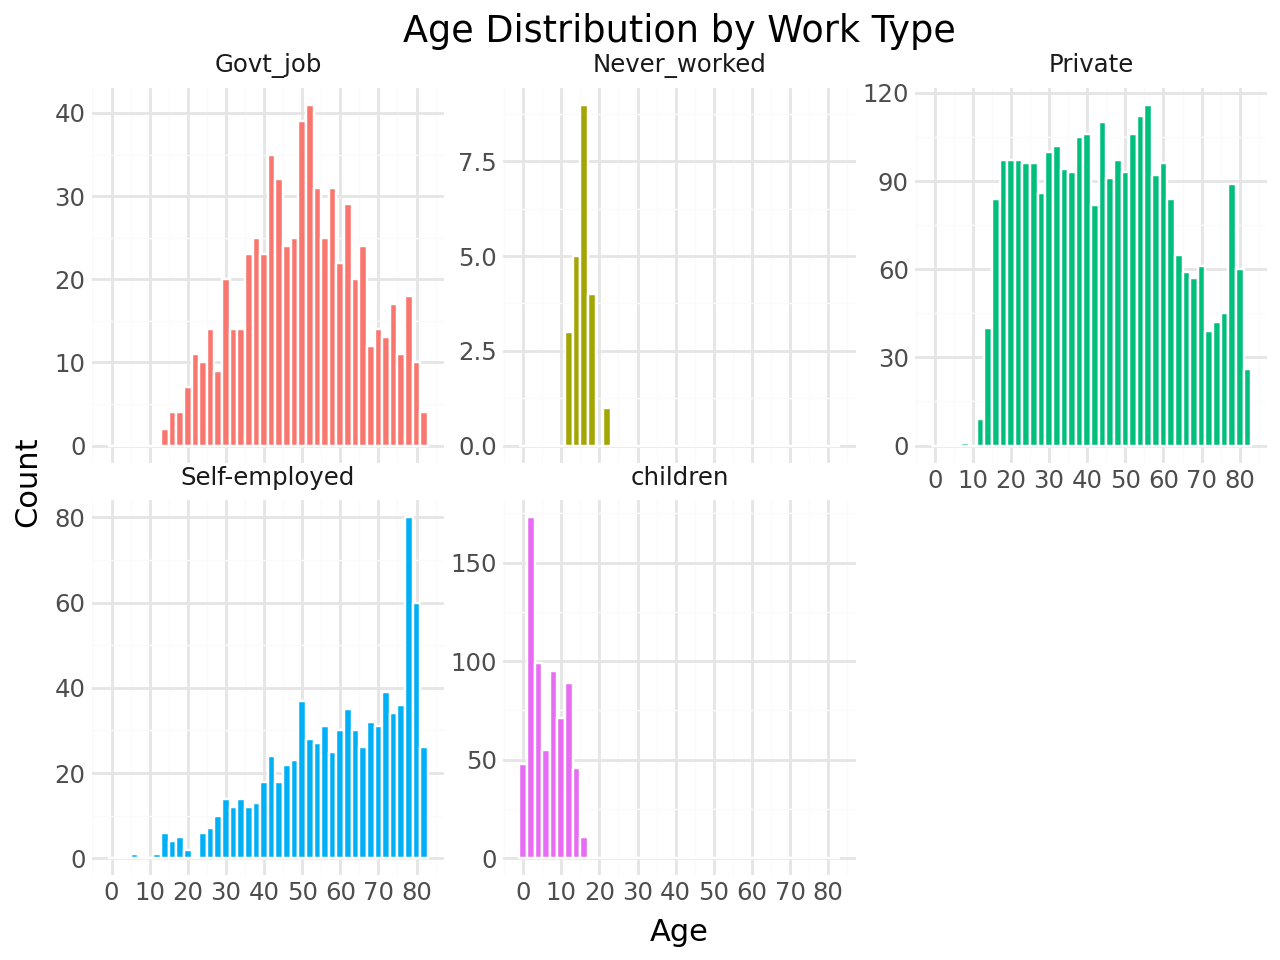

In [34]:
chart_all = (
    pln.ggplot(df, pln.aes(x='age', fill='work_type'))
    + pln.geom_histogram(binwidth=2, color='white', show_legend=False)
    + pln.facet_wrap('~work_type', scales='free_y')
    + pln.scale_x_continuous(breaks=range(0, 95, 10))
    + pln.labs(title='Age Distribution by Work Type', x='Age', y='Count')
    + pln.theme_minimal()
)

display(chart_all)

The majority of the working sampled people are adults. represent the entire population distribution.

#### *Residence type*

In [35]:
df["Residence_type"].value_counts()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

In [36]:
df["Residence_type"].describe()

count      5110
unique        2
top       Urban
freq       2596
Name: Residence_type, dtype: object

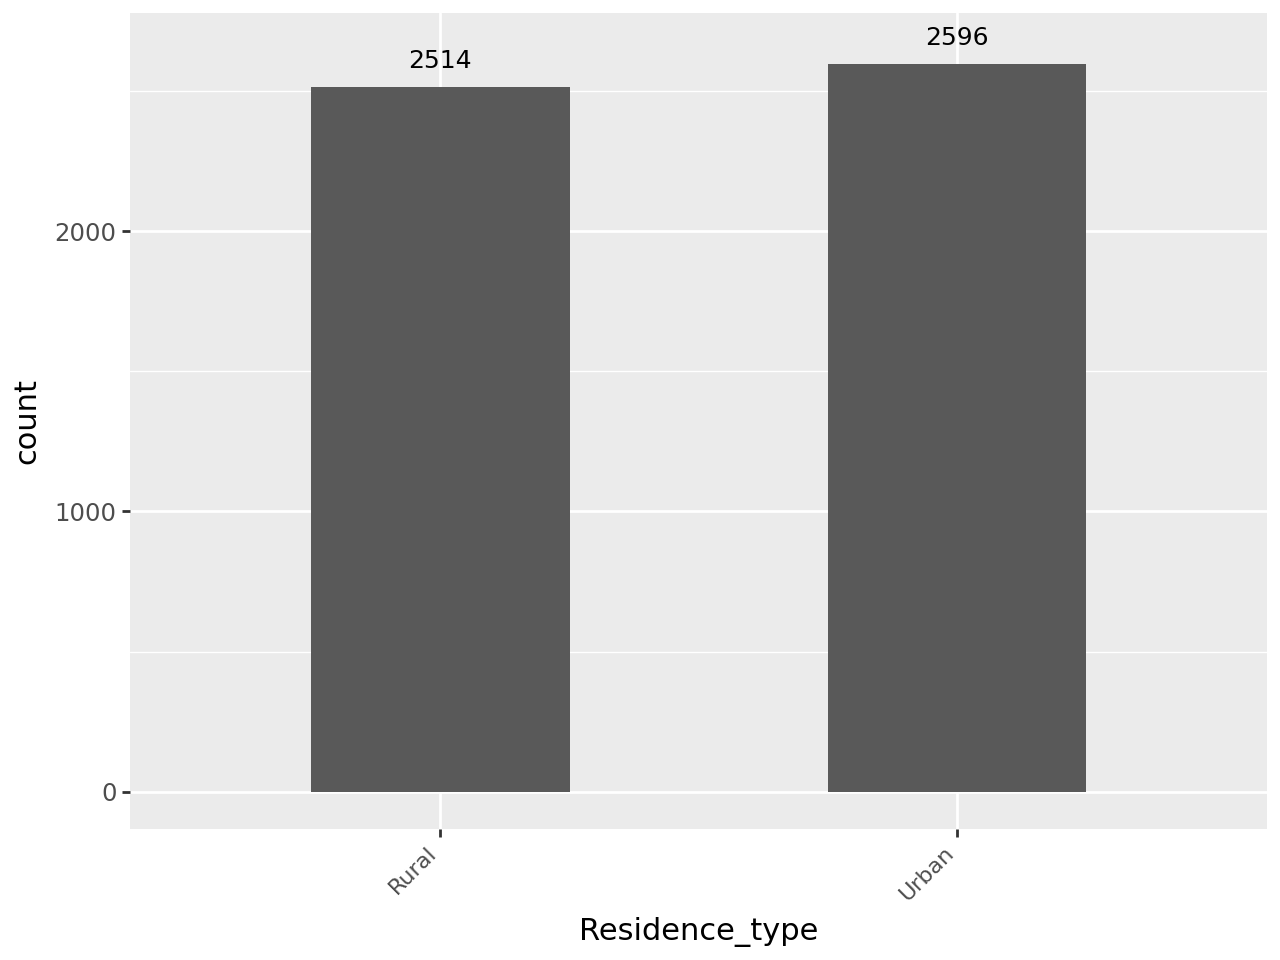

In [37]:
(
    pln.ggplot(df, pln.aes(x="Residence_type"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Average glucose level*

The data exhibits a bimodal distribution, comprising a primary normal distribution centered around a healthy avg glucose level, alongside a smaller, secondary normal distribution centered around an elevated average. This latter subpopulation likely represents individuals with potential pathological conditions.

In [38]:
df["avg_glucose_level"].value_counts()


avg_glucose_level
93.88     6
73.00     5
72.49     5
91.68     5
91.85     5
         ..
83.94     1
125.20    1
82.99     1
166.29    1
85.28     1
Name: count, Length: 3979, dtype: int64

In [39]:
df["avg_glucose_level"].describe()

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

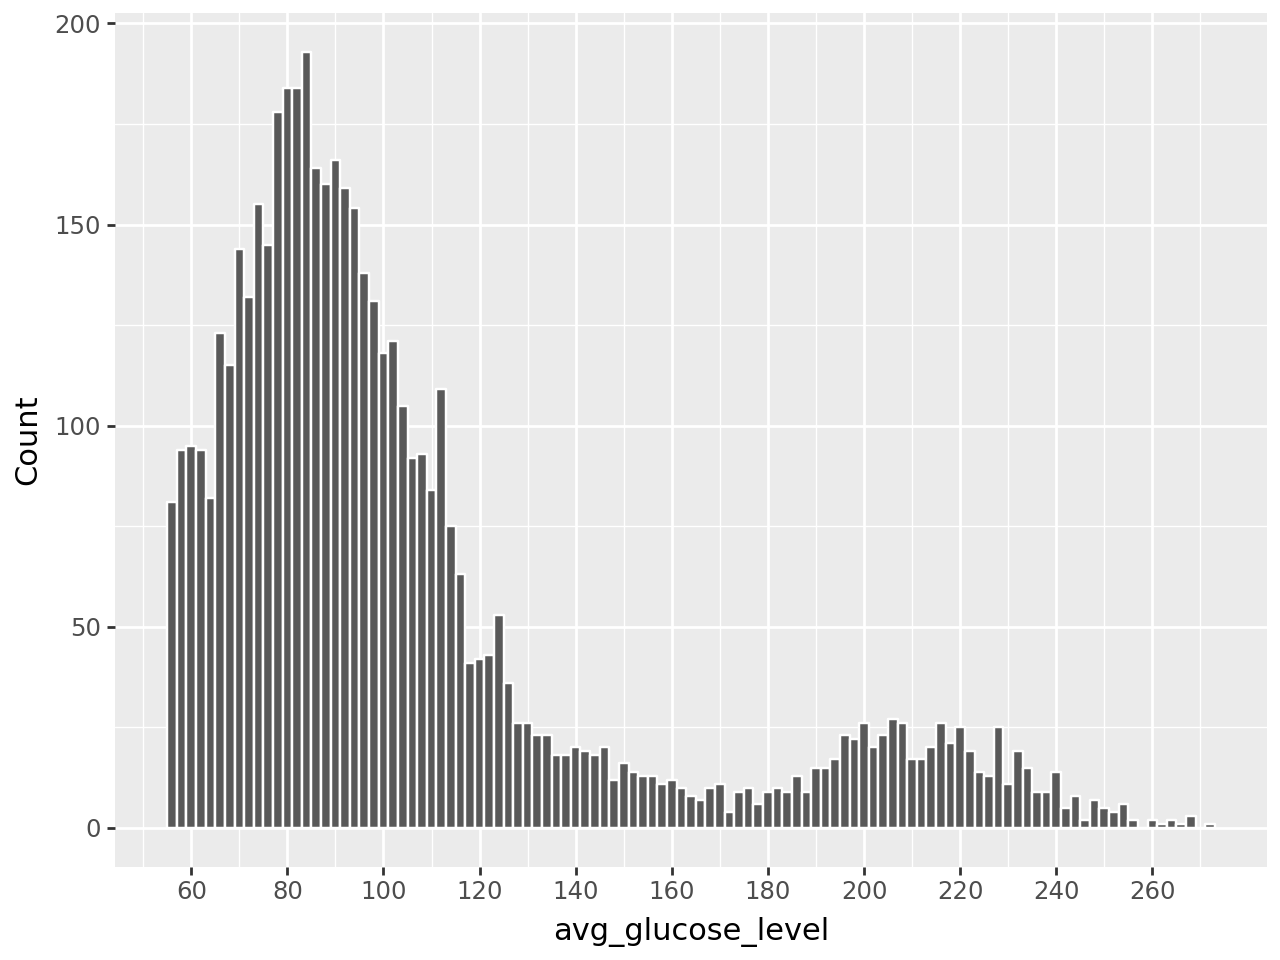

In [40]:
(
    pln.ggplot(df, pln.aes(x="avg_glucose_level"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 280, 20)
    )
    + pln.labs(x="avg_glucose_level", y="Count")
)

#### *BMI*

* **Distribution Profile:** The BMI metric exhibits a classic unimodal, right-skewed (positively skewed) distribution, with the peak mode centered around $25–28 \text{ kg/m}^2$.
* **Population Alignment:** This positive skew closely mirrors real-world adult epidemiological data, where population BMI values typically exhibit a concentration in the normal/overweight range with an extended upper tail corresponding to higher obesity classes.
* **Representativeness:** The overall shape and density spread demonstrate that the sample accurately reflects typical general-population health indicators, making it a reliable feature for downstream statistical analysis and predictive modeling.

In [41]:
df["bmi"].value_counts()

bmi
28.7    41
28.4    38
27.7    37
26.7    37
26.1    37
        ..
48.1     1
51.7     1
46.3     1
54.1     1
14.9     1
Name: count, Length: 418, dtype: int64

In [42]:
df["bmi"].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

Missing BMI values account for 201 out of 5,110 observations (~3.9%), which constitutes a negligible amount of data.

In [43]:
df["bmi"].isnull().sum()

np.int64(201)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_bin : Removed 201 rows containing non-finite values.


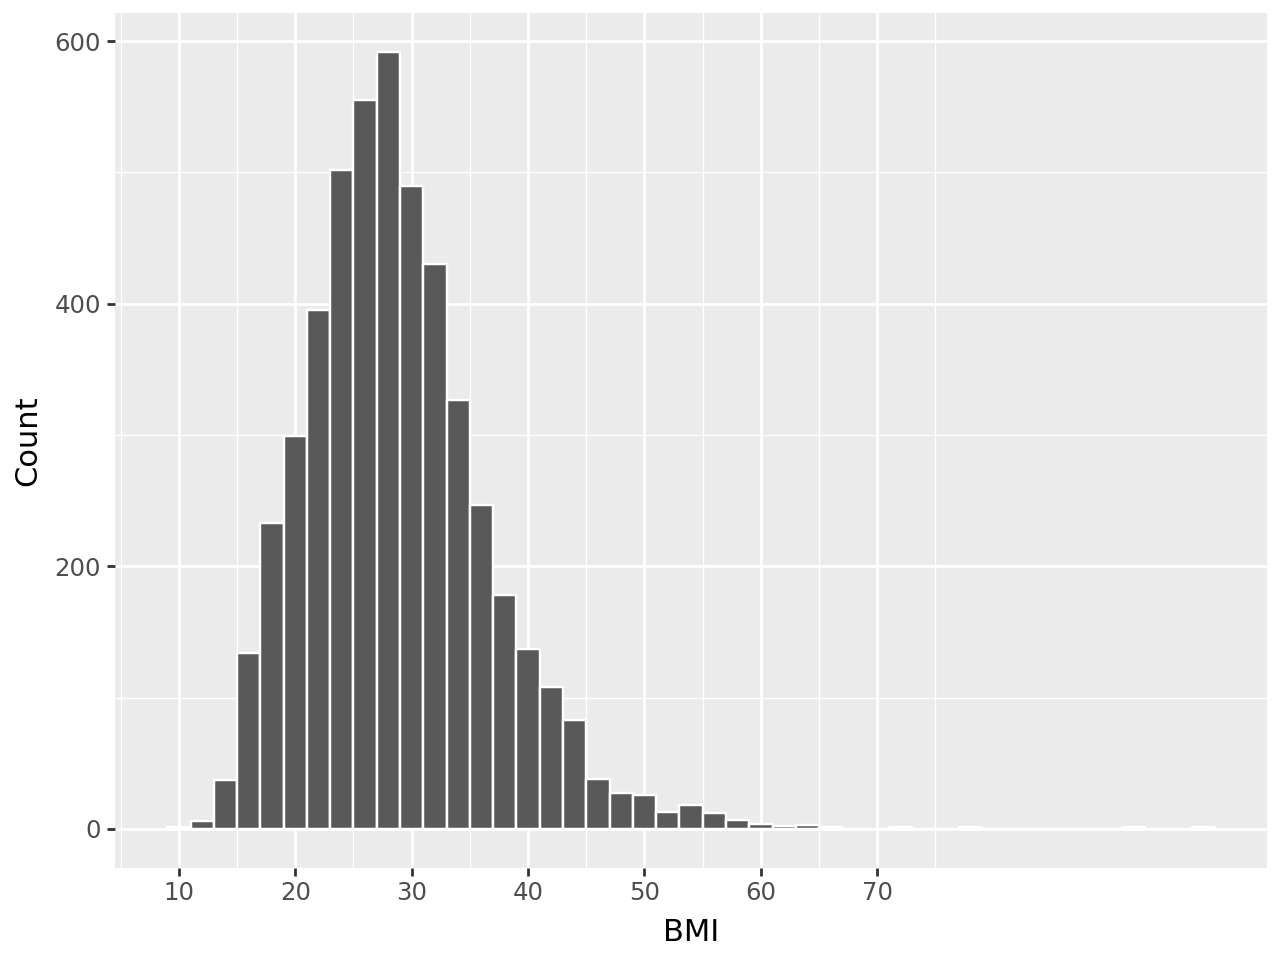

In [44]:
(
    pln.ggplot(df, pln.aes(x="bmi"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 80, 10)
    )
    + pln.labs(x="BMI", y="Count")
)

#### *Smoking status*

* **High Proportion of Missing Data:** The `smoking_status` feature contains **1,544 `Unknown` entries**, representing roughly **30% of the entire dataset**.
* **Clinical Significance Paradox:** Clinical literature strongly establishes tobacco smoking as a primary independent risk factor for ischemic and hemorrhagic stroke. Having a missing/unknown status for nearly a third of the cohort introduces substantial aleatoric uncertainty and potential bias into the model.
* **Domain Impact on Target Variable (`stroke`):** Because smoking status directly modulates vascular health and stroke probability, this high level of unobserved data limits the feature's predictive utility unless properly handled.
* **Modeling Strategy:**
  * **Explicit Categorical Encoding:** Retain `Unknown` as a standalone structural category rather than dropping rows, as the missingness pattern may not be Missing Completely at Random (MCAR) and could correlate with specific patient demographics or age groups.
  * **Sensitivity Analysis:** Evaluate model feature importance to monitor whether the `Unknown` category distorts signal propagation regarding stroke risk prediction.

In [45]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [46]:
df["smoking_status"].describe()

count             5110
unique               4
top       never smoked
freq              1892
Name: smoking_status, dtype: object

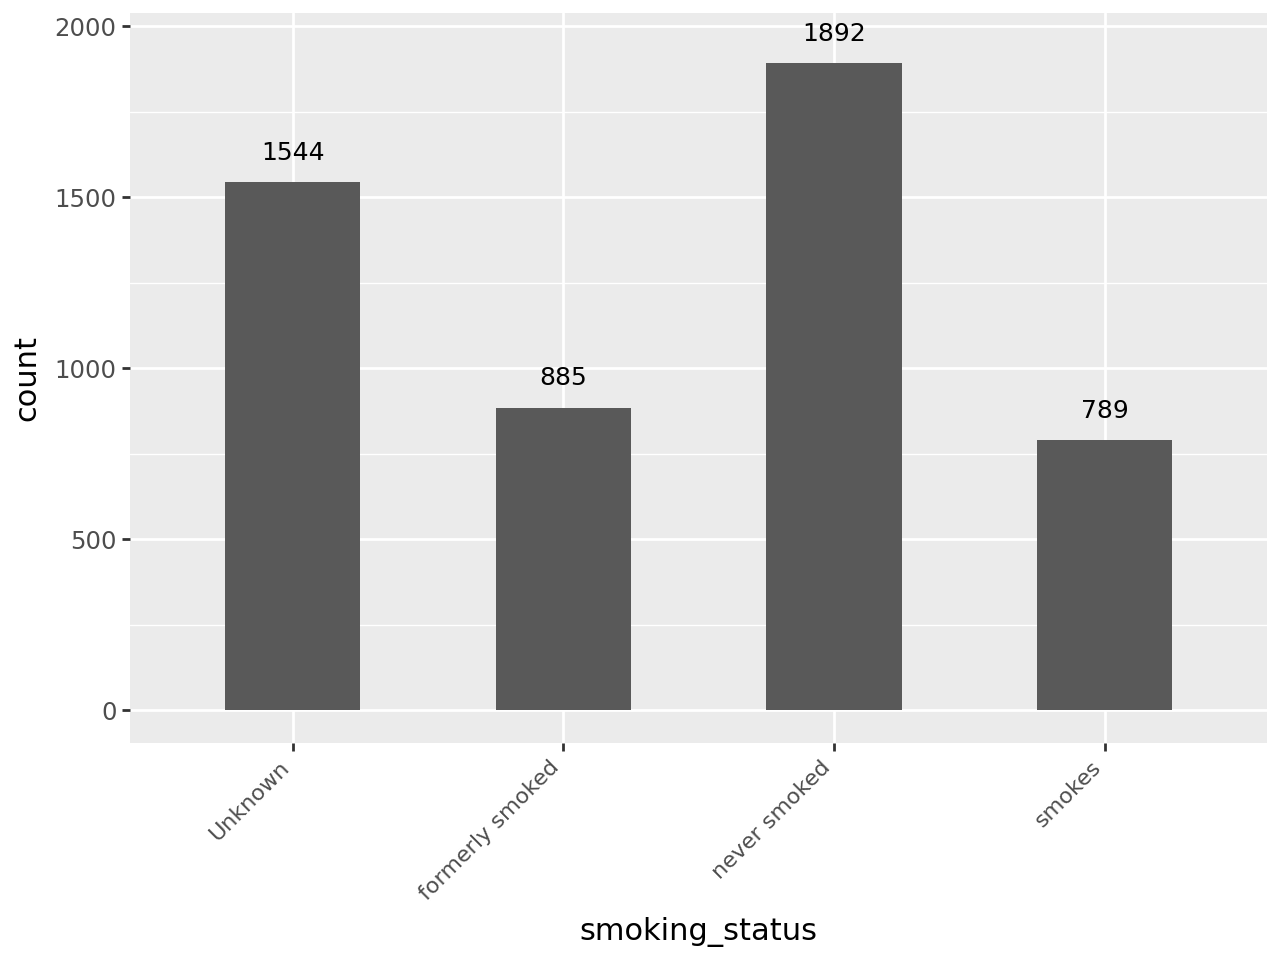

In [47]:
(
    pln.ggplot(df, pln.aes(x="smoking_status"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Stroke*

* **Real-World Alignment:** Only ~5% of patients in this dataset experienced a stroke. This accurately reflects real-life health data, where stroke is a relatively rare event.
* **The Model Trap:** A naive model predicting "No Stroke" for every patient would easily reach ~95% accuracy, yet fail completely at detecting actual stroke cases.
* **Key Strategy:**
  * Avoid relying on standard **Accuracy**.
  * Focus on **Recall** (Sensitivity) to capture as many true stroke cases as possible.
  * Apply class weighting during training to force the model to pay extra attention to stroke instances.

In [48]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [49]:
df["stroke"].describe()

count    5110.000000
mean        0.048728
std         0.215320
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: stroke, dtype: float64

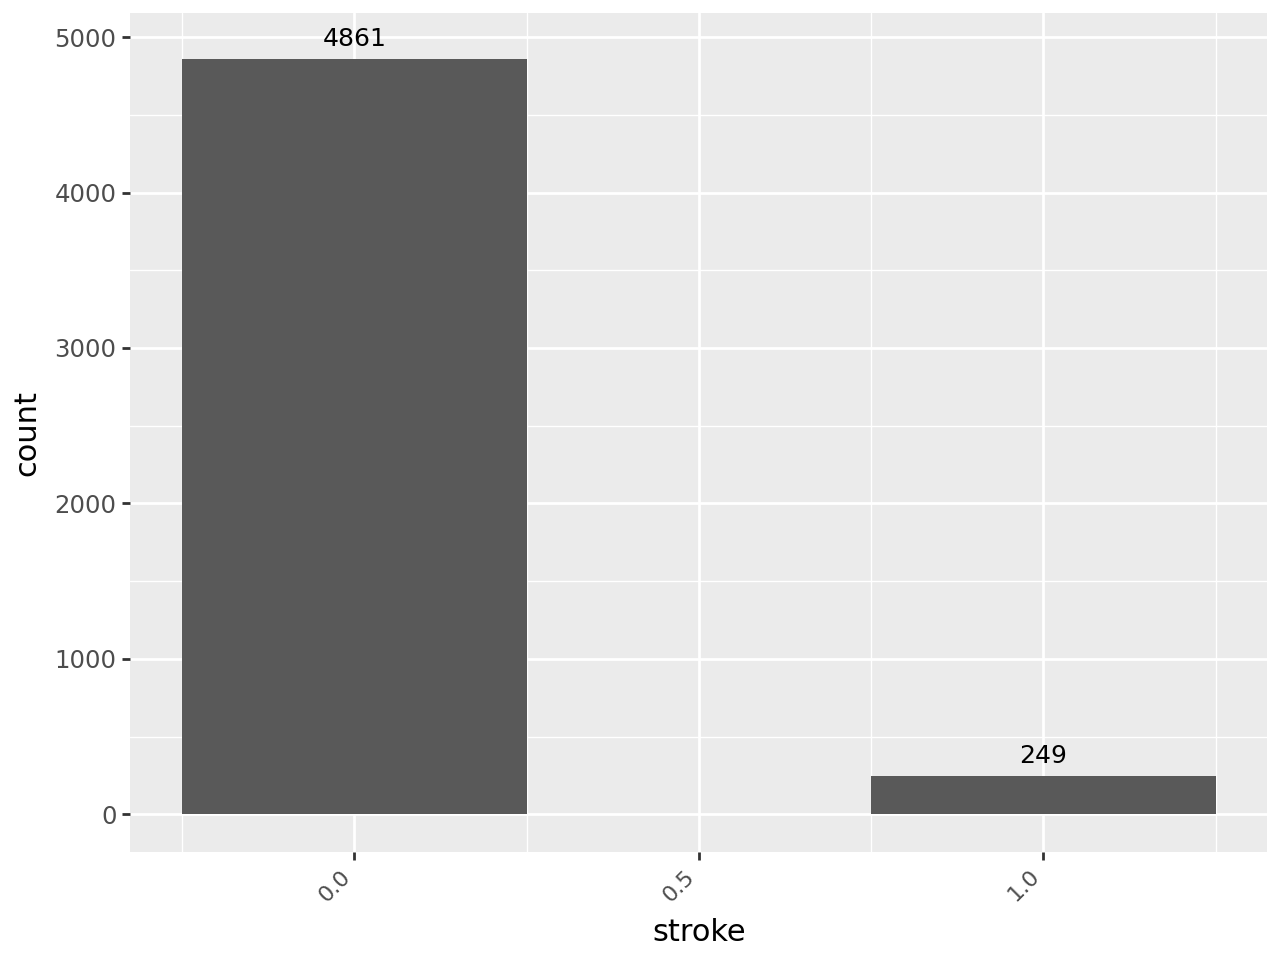

In [51]:
(
    pln.ggplot(df, pln.aes(x="stroke"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

## 3. Initial data cleaning and Inspecting